## İlk model XGBoost

Kütüphaneler



In [4]:
#XGBoost kurulumu
%pip install lightgbm
%pip install xgboost
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.9 MB/s eta 0:00:53
   ---------------------------------------- 1.0/100.2 MB 2.3 MB/s eta 0:00:44
    --------------------------------------- 1.6/100.2 MB 2.3 MB/s eta 0:00:44
    --------------------------------------- 2.1/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 2.6/100.2 MB 2.2 MB/s eta 0:00:44
   - -------------------------------------- 3.1/100.2 MB 2.3 MB/s eta 0:00:42
   - -------------------------------------- 3.9/100.2 MB 2.5 MB/s eta 0:00:39
   - -------------------------------------- 4.7/100.2 MB 2.7 MB/s eta 0:00:36
   -- ------------------------------------- 5.8/100.2 MB 2.9 MB/s eta 0:00:33
   -- ------------------

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

 Temiz verileri yükleyelim.

In [11]:
train = pd.read_csv('train_ready.csv')
test = pd.read_csv('test_ready.csv')
test_orijinal = pd.read_csv('test_x.csv')

# 2. Hedef değişken (y) ve özellikleri (X) ayıralım
X = train.drop('bilissel_performans_skoru', axis=1)
y = train['bilissel_performans_skoru']

In [12]:
#Kendi içinde doğrulama seti oluşturma
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=100,     # Oluşturulacak ağaç sayısı
    learning_rate=0.1,    # Öğrenme hızı
    max_depth=5           # Ağaçların maksimum derinliği
)

In [13]:
print("Model eğitiliyor, lütfen bekleyin...")
model.fit(X_train, y_train)

# Ayırdığımız o %20'lik Validation seti üzerinde tahmin yapalım
val_tahminleri = model.predict(X_val)

# Hataların karesinin ortalamasının karekökü RMSE
rmse = np.sqrt(mean_squared_error(y_val, val_tahminleri))

print(f"\n İlk Baseline XGBoost RMSE Skorumuz: {rmse:.4f}")

Model eğitiliyor, lütfen bekleyin...

 İlk Baseline XGBoost RMSE Skorumuz: 1.2418


#### XGBoost'un önem derecelerini heatmapimizle kıyaslayalım.

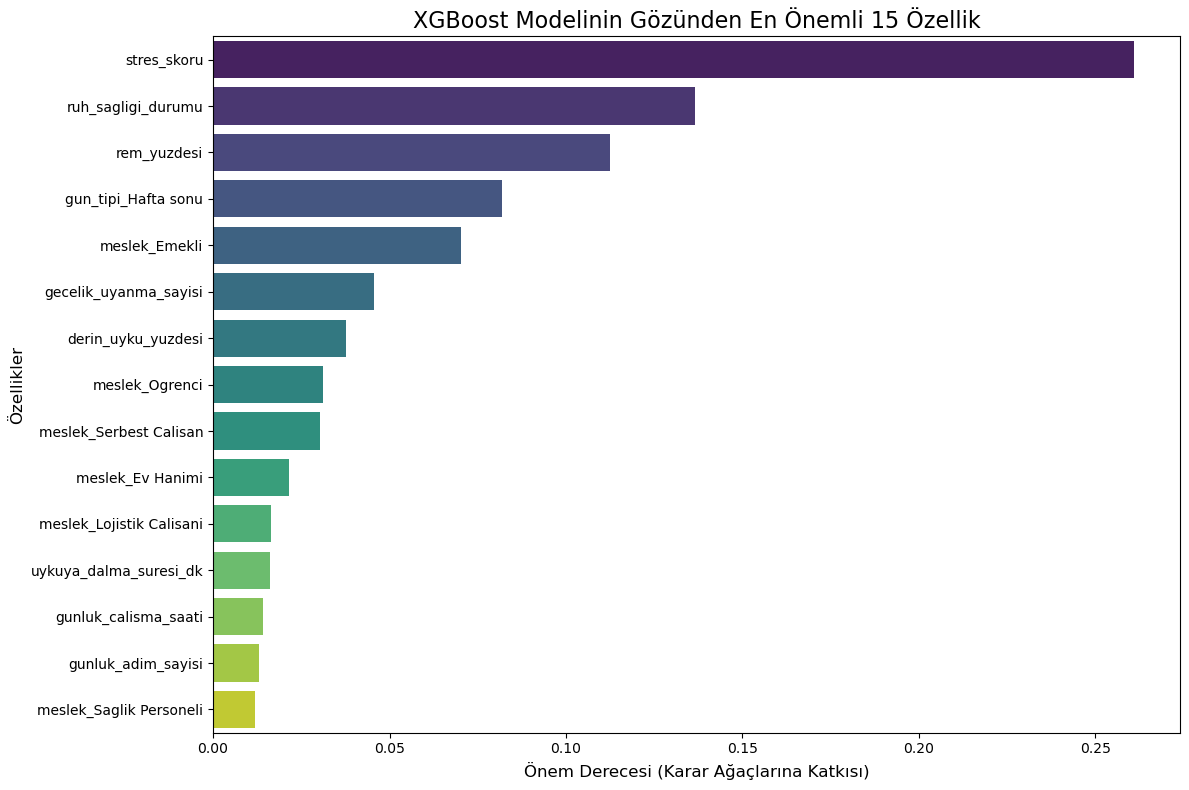

In [17]:
#1. Modelin içinden özellik önem derecelerini çekelim
onem_dereceleri = model.feature_importances_

# 2. Bu dereceleri kolon isimleriyle eşleştirip bir tablo (DataFrame) yapalım
onem_tablosu = pd.DataFrame({
    'Ozellik': X_train.columns,
    'Onem': onem_dereceleri
})

# 3. Önem derecesine göre büyükten küçüğe sıralayalım
onem_tablosu = onem_tablosu.sort_values(by='Onem', ascending=False)

# 4. En önemli ilk 15 özelliği şık bir grafiğe dökelim
plt.figure(figsize=(12, 8))
sns.barplot(x='Onem', y='Ozellik', 
            data=onem_tablosu.head(15),
            hue='Ozellik',
            palette='viridis',
           legend =False
           )           

plt.title('XGBoost Modelinin Gözünden En Önemli 15 Özellik', fontsize=16)
plt.xlabel('Önem Derecesi (Karar Ağaçlarına Katkısı)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.tight_layout()
plt.show()

#### Tuning aşaması.


In [19]:
# 1. XGBoost'un denemesini istediğimiz parametre uzayını (ihtimalleri) yazıyoruz
param_grid = {
    'n_estimators': [100, 200, 500],          # Ağaç sayısı
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Öğrenme hızı
    'max_depth': [3, 5, 7, 10],               # Ağaç derinliği
    'subsample': [0.8, 0.9, 1.0],             # Her ağaçta verinin yüzde kaçı kullanılsın
    'colsample_bytree': [0.8, 0.9, 1.0]       # Her ağaçta kolonların yüzde kaçı kullanılsın
}

# 2. Temel modelimizi tanımlıyoruz
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 3. Randomized Search sistemini kuruyoruz
# n_iter=20: Toplam 20 farklı rastgele kombinasyon deneyecek 
# cv=3: Veriyi 3'e bölüp çapraz doğrulama yapacak ki ezberlemesin
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,               
    scoring='neg_root_mean_squared_error', # Amacımız RMSE'yi düşürmek
    cv=3,
    verbose=1,               # Çalışırken bize bilgi versin
    random_state=42,
    n_jobs=-1                # Bilgisayarın tüm işlemci çekirdeklerini kullan (Turbo mod)
)

print("İnce ayar başladı, model 20 farklı kombinasyon deniyor...")
random_search.fit(X_train, y_train)

# 4. En iyi sonuçları ekrana yazdırıyoruz
en_iyi_model = random_search.best_estimator_
yeni_tahminler = en_iyi_model.predict(X_val)
yeni_rmse = np.sqrt(mean_squared_error(y_val, yeni_tahminler))

print(f"\nBulunan En İyi Parametreler: {random_search.best_params_}")
print(f"Yeni İnce Ayarlı RMSE Skorumuz: {yeni_rmse:.4f}")

İnce ayar başladı, model 20 farklı kombinasyon deniyor...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Bulunan En İyi Parametreler: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Yeni İnce Ayarlı RMSE Skorumuz: 1.2313


#### Yeni ayarlarımızla test data seti üstünde işlem yapalım.

In [24]:
# 1. RandomizedSearch'ün bulduğu parametreleri otomatik çekiyoruz
en_iyi_parametreler = random_search.best_params_
print(f"Kullanılan Parametreler: {en_iyi_parametreler}")

# 2. Final modelimizi tanımlıyoruz 
# (** işareti, sözlük içindeki parametreleri otomatik olarak XGBoost'un içine yerleştirir)
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **en_iyi_parametreler 
)

# 3. DİKKAT: Artık X_train değil, verimizin %100'ü olan 'X' ve 'y' ile eğitiyoruz!
print("\nFinal modeli tüm veriyle eğitiliyor...")
final_model.fit(X, y)

# 4. Hiç görmediğimiz test setini (test_ready.csv) modele verip tahminleri alıyoruz
final_tahminler = final_model.predict(test)

# 5. Teslim (Submission) dosyasını oluşturma
# SADECE id'leri alabilmek için ham test dosyasını okuyoruz (dosya adın farklıysa 'test.csv' kısmını düzelt)


# id ve hedef kolonu birleştiriyoruz
submission = pd.DataFrame({
    'id': test_orijinal['id'],
    'bilissel_performans_skoru': final_tahminler
})

# 6. CSV olarak dışarı aktarma
submission.to_csv('final_tahminler_xgboost.csv', index=False)
print("\n✅ Operasyon Tamam! 'id' ve 'bilissel_performans_skoru' kolonlarını içeren final_tahminler_xgboost.csv klasörüne kaydedildi.")

Kullanılan Parametreler: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Final modeli tüm veriyle eğitiliyor...

✅ Operasyon Tamam! 'id' ve 'bilissel_performans_skoru' kolonlarını içeren final_tahminler_xgboost.csv klasörüne kaydedildi.


#### Farklı modeller deneyelim.


In [29]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("Modeller arenaya çıkıyor, lütfen bekleyin...\n")

# 1. LightGBM Modeli (Microsoft'un algoritması - Tabular veride çok iddialıdır)
print("1/2: LightGBM eğitiliyor...")
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_tahmin = lgb_model.predict(X_val)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_tahmin))

# 2. Random Forest Modeli (Süresi XGBoost ve LightGBM'den biraz daha uzun sürebilir)
print("2/2: Random Forest eğitiliyor...")
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_tahmin = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_tahmin))

# 3. Sonuç Tablosu
print("\n" + "="*40)
print("  MODEL KARŞILAŞTIRMA SONUÇLARI  ")
print("="*40)
print(f"XGBoost (İnce Ayarlı)   : 1.2313")
print(f"LightGBM (Standart)     : {lgb_rmse:.4f}")
print(f"Random Forest (Standart): {rf_rmse:.4f}")
print("="*40)

Modeller arenaya çıkıyor, lütfen bekleyin...

1/2: LightGBM eğitiliyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001833 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 46
[LightGBM] [Info] Start training from score 5.913723
2/2: Random Forest eğitiliyor...

  MODEL KARŞILAŞTIRMA SONUÇLARI  
XGBoost (İnce Ayarlı)   : 1.2313
LightGBM (Standart)     : 1.2332
Random Forest (Standart): 1.2926


#### Çift modelli yaklaşım.


In [33]:
# Modelleri baştan tanımlayalım (Temiz X_train ve X_val verisiyle)
print("1/2: İnce Ayarlı XGBoost eğitiliyor...")
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    subsample=0.8, 
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    colsample_bytree=0.9
)
xgb_model.fit(X_train, y_train)
xgb_tahmin = xgb_model.predict(X_val)

print("2/2: Standart LightGBM eğitiliyor...")
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_tahmin = lgb_model.predict(X_val)

# === İŞTE SİHİR BURADA: ENSEMBLE (HARMANLAMA) ===
# İki modelin tahminlerini yarı yarıya (%50 - %50) karıştırıyoruz
harman_tahmin = (xgb_tahmin * 0.5) + (lgb_tahmin * 0.5)

# Yeni skorumuzu hesaplayalım
from sklearn.metrics import root_mean_squared_error
harman_rmse = root_mean_squared_error(y_val, harman_tahmin)

print("\n" + "="*40)
print(f"XGBoost Tek Başına : 1.2313")
print(f"LightGBM Tek Başına: 1.2332")
print(f"🔥 ENSEMBLE SKORU  : {harman_rmse:.4f}")
print("="*40)

1/2: İnce Ayarlı XGBoost eğitiliyor...
2/2: Standart LightGBM eğitiliyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2967
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 46
[LightGBM] [Info] Start training from score 5.913723

XGBoost Tek Başına : 1.2313
LightGBM Tek Başına: 1.2332
🔥 ENSEMBLE SKORU  : 1.2278


#### Yeni karma modelimizin skorlarını dışa aktaralım.

In [16]:
import pandas as pd
import xgboost as xgb
import lightgbm as lgb

print("🚀 Şampiyon Ensemble Modeli Tüm Veriyle Eğitiliyor...\n")

# 1. İnce Ayarlı XGBoost'u TÜM VERİYLE (X, y) Eğitme
print("1/2: XGBoost sahada...")
final_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    subsample=0.8, 
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    colsample_bytree=0.9
)
final_xgb.fit(X, y)

# 2. Standart LightGBM'i TÜM VERİYLE (X, y) Eğitme
print("2/2: LightGBM sahada...")
final_lgb = lgb.LGBMRegressor(random_state=42)
final_lgb.fit(X, y)

# 3. Test Seti (test_ready.csv) Üzerinden Tahminleri Alma
print("\nTahminler alınıyor ve harmanlanıyor...")
xgb_test_tahmin = final_xgb.predict(test)
lgb_test_tahmin = final_lgb.predict(test)

# 4. ENSEMBLE: %50 XGBoost + %50 LightGBM
final_harman_tahmin = (xgb_test_tahmin * 0.5) + (lgb_test_tahmin * 0.5)

# 5. Teslim (Submission) Tablosunu Oluşturma

submission = pd.DataFrame({
    'id': test_orijinal['id'],
    'bilissel_performans_skoru': final_harman_tahmin
})

# 6. CSV'ye Çevirme
submission.to_csv('karma_model.csv', index=False)
print("\n 'karma_model.csv' dosyası hazır.")

🚀 Şampiyon Ensemble Modeli Tüm Veriyle Eğitiliyor...

1/2: XGBoost sahada...
2/2: LightGBM sahada...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2983
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 46
[LightGBM] [Info] Start training from score 5.913096

Tahminler alınıyor ve harmanlanıyor...

 'karma_model.csv' dosyası hazır.


#### Sadece LightGBM testi.

In [36]:

# 1. LightGBM'in denemesini istediğimiz parametre uzayı
lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63],          # LGBM'in en kritik ayarı (çok yüksek olursa ezberler)
    'max_depth': [-1, 5, 7, 10],         # -1 demek derinliği yaprak sayısına göre kendi ayarlasın demek
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# 2. Temel LightGBM modelini tanımlıyoruz (verbose=-1 gereksiz uyarıları kapatır)
lgb_base_model = lgb.LGBMRegressor(random_state=42, verbose=-1)

# 3. Randomized Search sistemini kuruyoruz (Yine 20 ihtimal, 3 parça = 60 deneme)
lgb_random_search = RandomizedSearchCV(
    estimator=lgb_base_model,
    param_distributions=lgb_param_grid,
    n_iter=20,               
    scoring='neg_root_mean_squared_error', 
    cv=3,
    verbose=1,               
    random_state=42,
    n_jobs=-1                
)

print("LightGBM ince ayar operasyonu başladı, 60 fit yapılacak...")
lgb_random_search.fit(X_train, y_train)

# 4. En iyi model ile skoru hesaplayalım
en_iyi_lgb = lgb_random_search.best_estimator_
lgb_yeni_tahmin = en_iyi_lgb.predict(X_val)
lgb_yeni_rmse = np.sqrt(mean_squared_error(y_val, lgb_yeni_tahmin))

print(f"\ Bulunan En İyi LGBM Parametreleri: {lgb_random_search.best_params_}")
print(f" Yeni İnce Ayarlı LightGBM Skorumuz: {lgb_yeni_rmse:.4f}")

LightGBM ince ayar operasyonu başladı, 60 fit yapılacak...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
\ Bulunan En İyi LGBM Parametreleri: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
 Yeni İnce Ayarlı LightGBM Skorumuz: 1.2338


LightGBM üstünde randomized search ile daha iyi çalışma parametresi bulamadık.


#### En iyi performans aldığımız ağırlıklı modelde ağırlıklarda değişiklik yapalım.
Scipy ile ağırlık bulma.

In [1]:

from scipy.optimize import minimize

print("🔍 Adım 1: Optimal Ağırlıklar Aranıyor...\n")

# 1. Modelleri X_train ile eğitip X_val üzerinde tahmin alalım
# (Altın ayarlı XGBoost ve standart LightGBM)
xgb_val_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, subsample=0.8, n_estimators=500, max_depth=5, learning_rate=0.05, colsample_bytree=0.9)
xgb_val_model.fit(X_train, y_train)
xgb_val_tahmin = xgb_val_model.predict(X_val)

lgb_val_model = lgb.LGBMRegressor(random_state=42)
lgb_val_model.fit(X_train, y_train)
lgb_val_tahmin = lgb_val_model.predict(X_val)

# 2. Optimizasyon Fonksiyonu: RMSE'yi hesaplayan ve minimize edilecek matematiksel denklem
def rmse_fonksiyonu(agirlik):
    w1 = agirlik[0]
    w2 = 1 - w1  # İkisinin toplamı mecburen 1 (Yani %100) olacak
    harman_tahmin = (w1 * xgb_val_tahmin) + (w2 * lgb_val_tahmin)
    return np.sqrt(mean_squared_error(y_val, harman_tahmin))

# 3. Scipy ile en iyi ağırlığı bulma (%50-%50'den başla, 0 ile 1 arasında ara)
baslangic = [0.5]
sinirlar = [(0, 1)]
optimizasyon_sonucu = minimize(rmse_fonksiyonu, baslangic, bounds=sinirlar)

opt_w1 = optimizasyon_sonucu.x[0]
opt_w2 = 1 - opt_w1
opt_rmse = optimizasyon_sonucu.fun

print(f"🎯 Matematiksel Olarak Kusursuz Ağırlıklar Bulundu!")
print(f"   XGBoost Ağırlığı : %{opt_w1*100:.2f}")
print(f"   LightGBM Ağırlığı: %{opt_w2*100:.2f}")
print(f"   Dip Yapan RMSE   : {opt_rmse:.4f}\n")


print("🚀 Adım 2: Bulunan Ağırlıklarla Final Modelleri Tüm Veriyle Eğitiliyor...\n")

# 4. Modelleri tüm veri (X, y) ile baştan eğitelim
final_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, subsample=0.8, n_estimators=500, max_depth=5, learning_rate=0.05, colsample_bytree=0.9)
final_xgb.fit(X, y)

final_lgb = lgb.LGBMRegressor(random_state=42)
final_lgb.fit(X, y)

# 5. Orijinal Test seti üzerinden tahminleri alalım
xgb_test_tahmin = final_xgb.predict(test)
lgb_test_tahmin = final_lgb.predict(test)

# 6. Bulduğumuz o "Kusursuz Ağırlıkları" gerçek test tahminlerine uygulayalım
final_kusursuz_tahmin = (opt_w1 * xgb_test_tahmin) + (opt_w2 * lgb_test_tahmin)

# 7. Teslim (Submission) Tablosunu Oluşturma ve Kaydetme
submission = pd.DataFrame({
    'id': test_orijinal['id'],
    'bilissel_performans_skoru': final_kusursuz_tahmin
})

submission.to_csv('karma_weighted.csv', index=False)
print("✅ Operasyon Tamam! 'karma_weighted.csv' dosyası yüklenebilir durumda.")

🔍 Adım 1: Optimal Ağırlıklar Aranıyor...



NameError: name 'xgb' is not defined

In [14]:

# 1. CatBoost modelini tanımlayalım
# Standart ayarları bile çok güçlüdür ama kontrolü baştan elimize alıyoruz
cat_model = CatBoostRegressor(
    iterations=1000,          # Maksimum ağaç sayısı
    learning_rate=0.05,       # Öğrenme hızı
    depth=6,                  # Ağaç derinliği (XGBoost'a benzer şekilde başlatalım)
    eval_metric='RMSE',       # Optimizasyon hedefimiz
    random_seed=42,
    od_type='Iter',           # Aşırı öğrenmeyi durdurma (Overfitting Detector)
    od_wait=50,               # 50 adım boyunca RMSE düşmezse eğitimi erkenden keser
    verbose=100               # Sadece her 100 adımda bir ekrana bilgi bassın
)

# 2. Modeli Eğitelim
# eval_set ile modelin canlı canlı kendini test etmesini sağlıyoruz
print("Model eğitiliyor, simetrik (oblivious) ağaçlar kuruluyor...\n")
cat_model.fit(
    X_train, y_train, 
    eval_set=(X_val, y_val), 
    use_best_model=True       # En düşük RMSE'yi bulduğu anı kaydeder
)

# 3. Tahmin ve Skor Hesaplama
cat_val_tahmin = cat_model.predict(X_val)
cat_rmse = np.sqrt(mean_squared_error(y_val, cat_val_tahmin))

print("\n" + "="*45)
print(f"CatBoost (Temel) RMSE Skoru: {cat_rmse:.5f}")
print("="*45)

Model eğitiliyor, simetrik (oblivious) ağaçlar kuruluyor...

0:	learn: 2.1720910	test: 2.1828201	best: 2.1828201 (0)	total: 150ms	remaining: 2m 29s
100:	learn: 1.2532542	test: 1.2640872	best: 1.2640872 (100)	total: 686ms	remaining: 6.1s
200:	learn: 1.2196627	test: 1.2400672	best: 1.2400672 (200)	total: 1.28s	remaining: 5.09s
300:	learn: 1.2030751	test: 1.2329806	best: 1.2329806 (300)	total: 1.87s	remaining: 4.33s
400:	learn: 1.1897874	test: 1.2305453	best: 1.2305328 (399)	total: 2.33s	remaining: 3.48s
500:	learn: 1.1778687	test: 1.2290513	best: 1.2290513 (500)	total: 2.81s	remaining: 2.8s
600:	learn: 1.1672110	test: 1.2285794	best: 1.2285794 (600)	total: 3.33s	remaining: 2.21s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.228523834
bestIteration = 605

Shrink model to first 606 iterations.

CatBoost (Temel) RMSE Skoru: 1.22852


In [17]:

# 1. İnce Ayarlı XGBoost'u Hızlıca Eğitelim
print("1/3: XGBoost eğitiliyor...")
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, subsample=0.8, n_estimators=500, max_depth=5, learning_rate=0.05, colsample_bytree=0.9)
xgb_model.fit(X_train, y_train)
xgb_val_tahmin = xgb_model.predict(X_val)

# 2. Standart LightGBM'i Hızlıca Eğitelim
print("2/3: LightGBM eğitiliyor...")
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_val_tahmin = lgb_model.predict(X_val)

# 3. HARMANLAMA (CatBoost %40, XGBoost %30, LightGBM %30)
print("3/3: Güçler Birleştiriliyor (Ensemble)...")
uclu_harman_tahmin = (cat_val_tahmin * 0.4) + (xgb_val_tahmin * 0.3) + (lgb_val_tahmin * 0.3)

# 4. Final Skoru Hesaplama
uclu_rmse = np.sqrt(mean_squared_error(y_val, uclu_harman_tahmin))

print("\n" + "="*45)
print(f"XGBoost Tek Başına  : 1.2313")
print(f"LightGBM Tek Başına : 1.2332")
print(f"CatBoost Tek Başına : 1.2285")
print(f"🔥 3'LÜ ENSEMBLE    : {uclu_rmse:.5f}")
print("="*45)

1/3: XGBoost eğitiliyor...
2/3: LightGBM eğitiliyor...
3/3: Güçler Birleştiriliyor (Ensemble)...

XGBoost Tek Başına  : 1.2313
LightGBM Tek Başına : 1.2332
CatBoost Tek Başına : 1.2285
🔥 3'LÜ ENSEMBLE    : 1.22573


In [18]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge


# 1. Seviye 0 (İşçiler): Modellerimizi bir listeye koyuyoruz
# (İnce ayarlarını zaten bildiğimiz için direkt yazıyoruz)
isciler = [
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, subsample=0.8, n_estimators=500, max_depth=5, learning_rate=0.05, colsample_bytree=0.9)),
    ('lgb', lgb.LGBMRegressor(random_state=42, verbose=-1)),
    ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, random_seed=42, verbose=0))
]

# 2. Seviye 1 (Müdür/Meta-Model): Aşırı öğrenmeyi engelleyen Ridge Regresyon
mudur_model = Ridge(alpha=1.0)

# 3. Stacking Sistemini Kuruyoruz
# cv=5 demek, veriyi 5 parçaya bölüp birbirlerinin hatalarını öğrenerek ilerleyecek demek
stacking_model = StackingRegressor(
    estimators=isciler,
    final_estimator=mudur_model,
    cv=5,
    n_jobs=-1 # Bilgisayarın tüm çekirdeklerini kullan
)

# 4. Eğitiyoruz ve Tahmin Alıyoruz
print("Modeller 5-Fold CV ile eğitiliyor ve Müdür Model ağırlıkları öğreniyor. (Biraz sürebilir)...\n")
stacking_model.fit(X_train, y_train)

stacking_tahmin = stacking_model.predict(X_val)
stacking_rmse = np.sqrt(mean_squared_error(y_val, stacking_tahmin))

print("="*45)
print(f"👑 STACKING (YIĞINLAMA) SKORU: {stacking_rmse:.5f}")
print("="*45)

Modeller 5-Fold CV ile eğitiliyor ve Müdür Model ağırlıkları öğreniyor. (Biraz sürebilir)...

👑 STACKING (YIĞINLAMA) SKORU: 1.22561


In [19]:
print("🚀 Uçak Kapıdan Ayrılmadan Önceki Son Gank: Cinsiyetsiz XGB + LGBM...\n")

# 1. Cinsiyet kolonunu uçuruyoruz (İsimlendirmeye dikkat et kanka)
silinecek_kolon = 'cinsiyet' 
X_train_diyet = X_train.drop(silinecek_kolon, axis=1, errors='ignore')
X_val_diyet = X_val.drop(silinecek_kolon, axis=1, errors='ignore')

# 2. İnce Ayarlı XGBoost (Diyet Veriyle)
print("1/2: Cinsiyetsiz XGBoost eğitiliyor...")
xgb_diyet = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42, 
    subsample=0.8, 
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    colsample_bytree=0.9
)
xgb_diyet.fit(X_train_diyet, y_train)
xgb_diyet_tahmin = xgb_diyet.predict(X_val_diyet)

# 3. Standart LightGBM (Diyet Veriyle)
print("2/2: Cinsiyetsiz LightGBM eğitiliyor...")
lgb_diyet = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_diyet.fit(X_train_diyet, y_train)
lgb_diyet_tahmin = lgb_diyet.predict(X_val_diyet)

# 4. HARMANLAMA (Sağlamcı yaklaşım: %50 XGBoost - %50 LightGBM)
print("\nTahminler %50-%50 harmanlanıyor...")
diyet_harman_tahmin = (xgb_diyet_tahmin * 0.5) + (lgb_diyet_tahmin * 0.5)

# 5. Skor Hesaplama
diyet_harman_rmse = root_mean_squared_error(y_val, diyet_harman_tahmin)

print("\n" + "="*45)
print(f"🎯 Hedef Rekor : 1.21645")
print(f"🔥 CİNSİYETSİZ XGB+LGBM RMSE : {diyet_harman_rmse:.5f}")
print("="*45)

🚀 Uçak Kapıdan Ayrılmadan Önceki Son Gank: Cinsiyetsiz XGB + LGBM...

1/2: Cinsiyetsiz XGBoost eğitiliyor...
2/2: Cinsiyetsiz LightGBM eğitiliyor...

Tahminler %50-%50 harmanlanıyor...


NameError: name 'root_mean_squared_error' is not defined

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error

print("🚀 Uçak Kapıdan Ayrılmadan Önceki Son Gank: Cinsiyetsiz XGB + LGBM...\n")

# 1. Cinsiyet kolonunu uçuruyoruz (İsimlendirmeye dikkat et kanka)
silinecek_kolon = 'cinsiyet' 
X_train_diyet = X_train.drop(silinecek_kolon, axis=1, errors='ignore')
X_val_diyet = X_val.drop(silinecek_kolon, axis=1, errors='ignore')

# 2. İnce Ayarlı XGBoost (Diyet Veriyle)
print("1/2: Cinsiyetsiz XGBoost eğitiliyor...")
xgb_diyet = xgb.XGBRegressor(
    objective='reg:squarederror', 
    random_state=42, 
    subsample=0.8, 
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    colsample_bytree=0.9
)
xgb_diyet.fit(X_train_diyet, y_train)
xgb_diyet_tahmin = xgb_diyet.predict(X_val_diyet)

# 3. Standart LightGBM (Diyet Veriyle)
print("2/2: Cinsiyetsiz LightGBM eğitiliyor...")
lgb_diyet = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_diyet.fit(X_train_diyet, y_train)
lgb_diyet_tahmin = lgb_diyet.predict(X_val_diyet)

# 4. HARMANLAMA (Sağlamcı yaklaşım: %50 XGBoost - %50 LightGBM)
print("\nTahminler %50-%50 harmanlanıyor...")
diyet_harman_tahmin = (xgb_diyet_tahmin * 0.5) + (lgb_diyet_tahmin * 0.5)

# 5. Skor Hesaplama (Eski sürümlerle de %100 uyumlu np.sqrt mantığı)
diyet_harman_rmse = np.sqrt(mean_squared_error(y_val, diyet_harman_tahmin))

print("\n" + "="*45)
print(f"🎯 Hedef Rekor : 1.21645")
print(f"🔥 CİNSİYETSİZ XGB+LGBM RMSE : {diyet_harman_rmse:.5f}")
print("="*45)

🚀 Uçak Kapıdan Ayrılmadan Önceki Son Gank: Cinsiyetsiz XGB + LGBM...

1/2: Cinsiyetsiz XGBoost eğitiliyor...
2/2: Cinsiyetsiz LightGBM eğitiliyor...

Tahminler %50-%50 harmanlanıyor...

🎯 Hedef Rekor : 1.21645
🔥 CİNSİYETSİZ XGB+LGBM RMSE : 1.22780
